# Lecture 9: Clustering

sklearn's comparison of clustering algorithms: https://scikit-learn.org/stable/auto_examples/cluster/plot_cluster_comparison.html.

![](https://scikit-learn.org/stable/_images/sphx_glr_plot_cluster_comparison_001.png)

In [1]:
import numpy as np, matplotlib.pyplot as plt
from sklearn import datasets, cluster
from sklearn.mixture import GaussianMixture

# K-means-like algorithms

- K-means: round/ellipsoidal clusters, Voronoi diagram
- Gaussian Mixture Model (GMM): fully probabilistic, ellipsoidal clusters

In [2]:
X, y = datasets.make_blobs(n_samples=200, n_features=2, centers=3, random_state=2)
X.shape, y.shape

((200, 2), (200,))

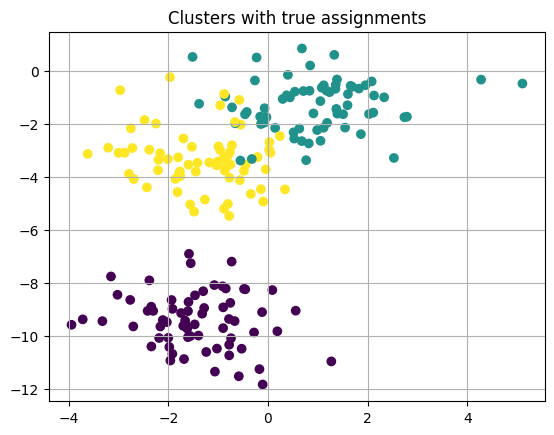

In [3]:
plt.scatter(X[:, 0], X[:, 1], c=y); plt.grid()
plt.title('Clusters with true assignments'); plt.gca();

In [4]:
cluster.KMeans(3, random_state=2, init='random', algorithm='lloyd').fit(X).cluster_centers_

array([[-1.43508018, -9.41561703],
       [ 0.81251172, -1.28293963],
       [-1.40499318, -3.57188487]])

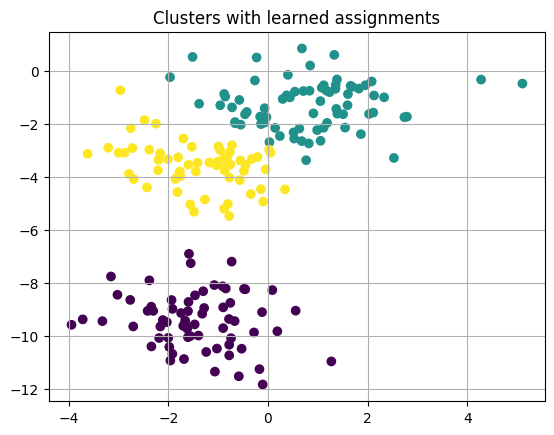

In [5]:
yhat = cluster.KMeans(3, random_state=2, init='random', algorithm='lloyd').fit(X).labels_
plt.scatter(X[:, 0], X[:, 1], c=yhat); plt.grid()
plt.title('Clusters with learned assignments'); plt.gca();

Note the misclassifications at the boundary of the teal and yellow clusters.

In [6]:
class MyKMeans:
    def __init__(self, K: int, init='random', max_iter=300, random_state=None):
        assert K > 0
        assert init == 'random'
        assert max_iter > 0
        self.K = K
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X: np.ndarray, y=None, quiet=True):
        N, _ = X.shape
        rng = np.random.RandomState(self.random_state)
        # `init == 'random'`, use random rows as centroids
        centroids = X[rng.choice(N, self.K), :]
        if not quiet: print(f"{X.shape=}, {centroids.shape=}")
        yhat = np.array([
            np.argmin(np.linalg.norm(X[n, :] - centroids, axis=1))
            for n in range(N)
        ])
        if not quiet: print("Initial assignments:", yhat)
        for _ in range(self.max_iter):
            # Update centroids
            for k in range(self.K):
                mask = yhat == k
                X[mask, :].mean(axis=0, out=centroids[k])
            # Update cluster assignments
            yhat = np.array([
                np.argmin(np.linalg.norm(X[n, :] - centroids, axis=1))
                for n in range(N)
            ])
        self.cluster_centers_ = centroids
        self.labels_ = yhat
        return self

In [7]:
MyKMeans(3).fit(X, quiet=False).cluster_centers_

X.shape=(200, 2), centroids.shape=(3, 2)
Initial assignments: [0 0 0 2 0 0 1 2 0 2 0 1 0 2 2 2 1 0 0 0 0 0 0 0 2 0 0 2 1 1 1 0 2 1 0 0 2
 2 0 2 1 2 1 1 0 2 1 2 1 1 2 1 1 2 0 0 1 0 1 1 2 2 0 2 2 0 2 0 2 1 0 0 0 2
 1 2 0 2 0 0 1 1 2 0 1 2 1 2 1 0 0 2 0 1 2 2 2 2 0 1 0 1 0 2 1 1 2 2 0 2 2
 2 1 2 2 0 1 1 1 2 0 1 1 0 0 1 2 1 0 0 0 1 2 2 1 2 0 2 1 1 0 0 2 0 1 2 2 2
 2 0 0 1 0 2 0 1 1 1 0 0 2 2 1 1 0 1 2 0 0 1 1 0 0 2 2 2 1 1 0 0 1 0 1 1 2
 0 0 2 2 0 2 2 0 0 2 1 0 2 1 1]


array([[-1.31445706, -3.447127  ],
       [ 0.92190942, -1.20085527],
       [-1.43508018, -9.41561703]])

In [8]:
def compare_K(X: np.ndarray, Ks: range, random_state: int):
    f, axs = plt.subplots(ncols=len(Ks), sharey=True, layout='constrained')
    for i, K in enumerate(Ks):
        yhat = MyKMeans(K, random_state=random_state).fit(X).labels_
        axs[i].scatter(X[:, 0], X[:, 1], c=yhat)
        axs[i].set_title(f"{K=}")
        axs[i].grid(True)
    return f

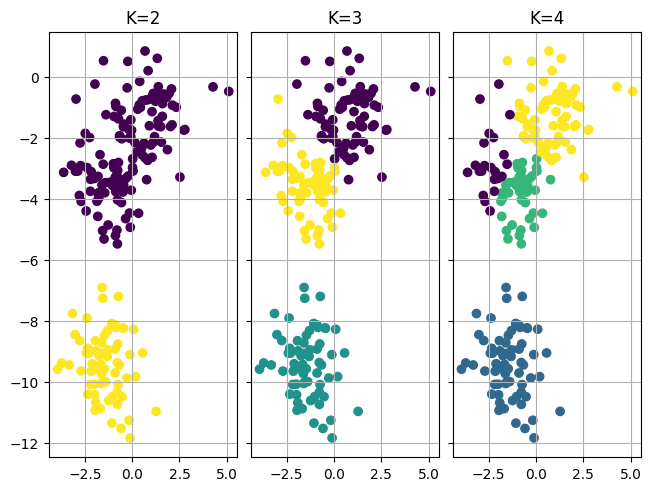

In [9]:
compare_K(X, range(2, 5), 2);

Looking at $K=4$, the algorithm is forced to cram in the 4th cluster, even though there are only 3 clusters in the data.

## Classify other points

Given learned centroids $\mu_k$, classify _new_ data points $x_n$:
$$
\hat y_n = \arg\min_{k \in 0,...,K-1} \lVert x_n - \mu_k \rVert
$$
Each point $x \in \mathbb R^F$ can be classified like this, so the space $\mathbb R^F$ can be split into $K$ regions corresponding to the $K$ clusters/classes.

The below plot is known as a [Voronoi diagram](https://en.wikipedia.org/wiki/Voronoi_diagram).

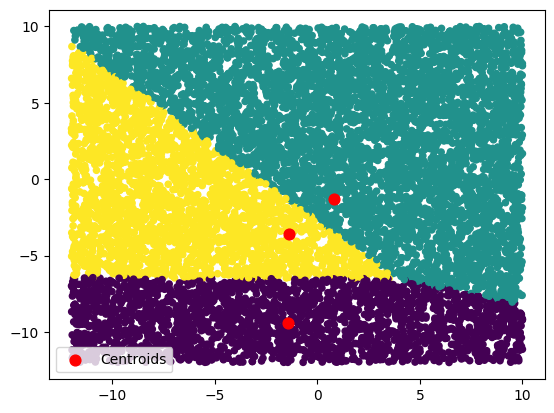

In [10]:
km = cluster.KMeans(3, random_state=2, init='random', algorithm='lloyd').fit(X)
Xnew = np.random.RandomState(5).uniform(-12, 10, size=(10_000, X.shape[1]))
yhat = km.predict(Xnew)
plt.scatter(Xnew[:, 0], Xnew[:, 1], c=yhat, s=20);
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], s=60, c='red', label='Centroids');
plt.legend();

## Try to learn non-spherical clusters

`KMeans` and `GaussianMixture` cannot do this:

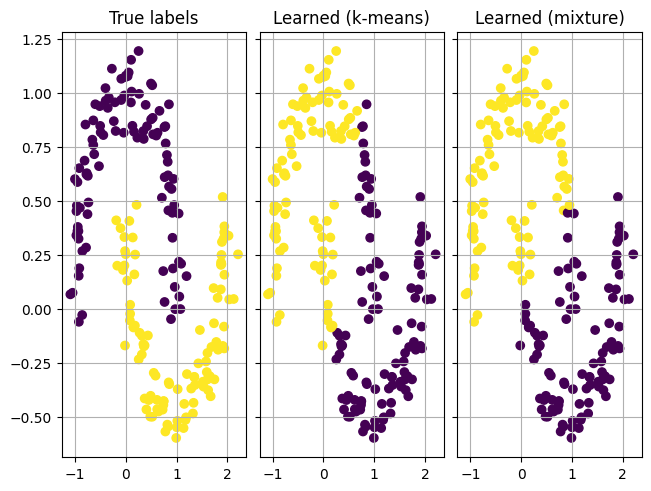

In [11]:
Xmoon, ymoon = datasets.make_moons(200, noise=0.1, random_state=5)
f, (a1, a2, a3) = plt.subplots(ncols=3, sharex=True, sharey=True, layout='constrained')
a1.scatter(Xmoon[:, 0], Xmoon[:, 1], c=ymoon)
a1.set_title('True labels')
a2.scatter(
    Xmoon[:, 0], Xmoon[:, 1], c=cluster.KMeans(2).fit_predict(Xmoon)
)
a2.set_title('Learned (k-means)')
a3.scatter(
    Xmoon[:, 0], Xmoon[:, 1], c=GaussianMixture(2).fit_predict(Xmoon)
)
a3.set_title('Learned (mixture)')
a1.grid(); a2.grid(); a3.grid()
f;

# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

- Can find clusters of arbitrary shapes.
- Does not require choosing the number of clusters beforehand.

Hyperparameters:
1. $\varepsilon > 0$: used to define $\varepsilon$-neighborhoods of points.
2. $\mathrm{MinPts} \in \{1,2,\dots\}$: used to define _core points_.

Original paper: [1]. Modern description: [2].

$\varepsilon$-neighborhood of point $x$ [2, Definition 1]:
$$
N_\varepsilon(x) = \{x_n \in \mathcal D: \lVert x - x_n \rVert \leq \varepsilon\}
$$

Types of points/observations [2, Definition 2]:
1. __Core point__ $x_n: |N_\varepsilon(x_n)| \geq \mathrm{MinPts}$.
2. __Border point__ $x_m \in N_\varepsilon(x_n)$, where $x_m$ is _not_ a core point, but is within the neighborhood of core point $x_n$.
3. __Noise point__: not a core point and not a border point.

Relations between points [1,2]:
1. __Direct density reachability.__ Point $q$ is directly density-reachable from point $c$ if $c$ is a core point and $q \in N_\varepsilon(c)$.
2. __Density reachability.__ Point $q$ is density reachable from core point $c_1$ if there's a sequence of core points $c_1,c_2,\dots,c_n$ such that $c_{i+1}$ is directly density reachable from $c_i$ _and_ $q$ is directly density reachable from the last core point $c_n$.
3. __Density connectedness.__ Points $p$ and $q$ are density connected if there is a core point $c$ such that $p$ and $q$ are both density-reachable from $c$.

__Cluster.__ A cluster is a non-empty subset $C$ of data points satisfying the following conditions:
1. Maximality: if a core point $c \in C$ and $q$ is density reachable from $c$, then $q \in C$.
2. Connectivity: each pair of points $p,q \in C$ is density connected.

### References

1. Ester, Martin, Hans-Peter Kriegel, and Xiaowei Xu. “A Density-Based Algorithm for Discovering Clusters in Large Spatial Databases with Noise.” KDD-96 Proceedings 96, no. 34 (1996): 226–31. https://cdn.aaai.org/KDD/1996/KDD96-037.pdf.
2. Hahsler, Michael, Matthew Piekenbrock, and Derek Doran. “Dbscan: Fast Density-Based Clustering with R.” Journal of Statistical Software 91, no. 1 (2019). https://doi.org/10.18637/jss.v091.i01.

In [12]:
cluster.DBSCAN().fit(Xmoon)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.5
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [13]:
cluster.DBSCAN(eps=0.2).fit_predict(Xmoon)

array([ 0,  1,  2,  2,  2,  2,  0,  1,  1,  1,  2,  1,  1,  1,  1,  0,  1,
        1,  0,  2,  2,  1,  1,  2,  1,  1,  2,  1,  1,  1,  1,  2,  1,  2,
        1,  1,  2,  0,  2,  1,  2,  1,  2,  1,  1,  1,  2,  1,  2,  0,  0,
        0,  1,  2,  0,  1,  2,  0,  1,  0,  2,  2,  1,  2,  1,  1,  0,  2,
        1,  1,  1,  2,  1,  2,  0,  1,  1,  2,  1,  1,  2,  2,  1,  1,  1,
        1,  1,  1,  2,  2,  1,  0, -1,  2,  1,  2,  2,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  2,  1,  0,  1,  1,  1,  2,  2,  1,  0,  1,  2,
        1,  2,  1,  2,  2,  2,  2,  2,  1,  2,  1,  1,  2,  2,  2,  1,  2,
        1,  2,  1,  1,  1,  2,  1,  1,  1,  1,  2,  0,  1,  1,  0,  0,  0,
        2,  2,  1,  2,  2,  1,  1,  1,  1,  2,  0,  2,  0,  2,  1,  1,  1,
        2,  0,  2,  1,  0,  2,  0,  2,  0,  1,  1,  2,  1,  1,  1,  1,  2,
        0,  2,  1,  2,  0,  2,  2,  1,  1,  2,  0,  2,  1])

One point is classified as $-1$ (noise, "outlier").

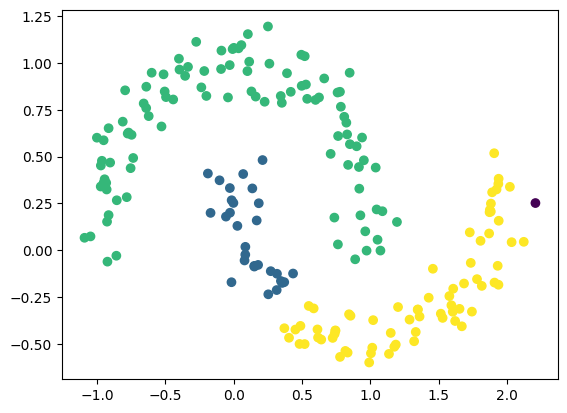

In [14]:
plt.scatter(
    Xmoon[:, 0], Xmoon[:, 1], c=cluster.DBSCAN(eps=0.2).fit_predict(Xmoon)
);

The algorithm was able to learn the green horseshoe-shaped cluster.

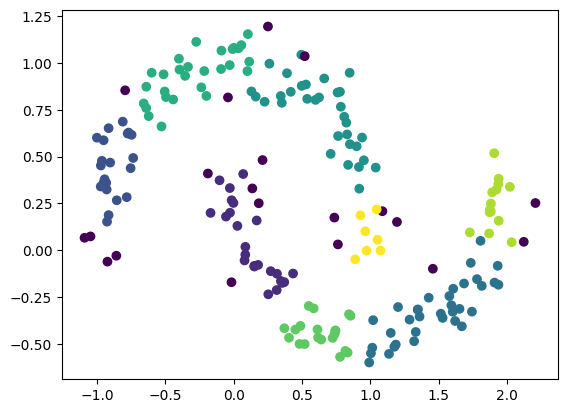

In [15]:
plt.scatter(Xmoon[:, 0], Xmoon[:, 1], c=cluster.DBSCAN(eps=0.15).fit_predict(Xmoon));

Smaller $\varepsilon$ leads to higher segmentation, smaller clusters and more noise/outlier points.